In [1]:
from pathlib import Path

import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

data = pd.read_excel('initial_vs_new_SMILES_models_.xlsx')

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

print("\nDataset labels:")
display(data["dataset"].value_counts(dropna=False))

display(data.head())

Shape: (63, 45)
Columns:
['Unnamed: 0', 'Initial_SMILES', 'New_SMILES', 'ee', 'dataset', 'Sterimol_Beta_R1_L_Chalcone', 'Sterimol_Beta_R1_B1_Chalcone', 'Sterimol_Beta_R1_B5_Chalcone', 'Sterimol_Beta_R2_L_Chalcone', 'Sterimol_Beta_R2_B1_Chalcone', 'Sterimol_Beta_R2_B5_Chalcone', 'Sterimol_Alpha_R1_L_Chalcone', 'Sterimol_Alpha_R1_B1_Chalcone', 'Sterimol_Alpha_R1_B5_Chalcone', 'Alpha_Charge_Chalcone', 'Beta_Charge_Chalcone', 'Acceptor_Charge_Chalcone', 'Beta_R1_EN_Chalcone', 'Beta_R1_Charge_Head_Chalcone', 'Beta_R1_Charge_Sum3_Chalcone', 'Beta_R2_EN_Chalcone', 'Beta_R2_Charge_Head_Chalcone', 'Beta_R2_Charge_Sum3_Chalcone', 'Alpha_R1_EN_Chalcone', 'Alpha_R1_Charge_Head_Chalcone', 'Alpha_R1_Charge_Sum3_Chalcone', 'Diff_Charge_Beta_Alpha_Chalcone', 'Diff_Charge_Acceptor_Alpha_Chalcone', 'Sterimol_Alpha_R1_L_Thiol', 'Sterimol_Alpha_R1_B1_Thiol', 'Sterimol_Alpha_R1_B5_Thiol', 'Sterimol_Alpha_R2_L_Thiol', 'Sterimol_Alpha_R2_B1_Thiol', 'Sterimol_Alpha_R2_B5_Thiol', 'Alpha_Charge_Thiol', 'Beta_Ch

dataset
train    53
test     10
Name: count, dtype: int64

,Unnamed: 0,Initial_SMILES,New_SMILES,ee,dataset,Sterimol_Beta_R1_L_Chalcone,Sterimol_Beta_R1_B1_Chalcone,Sterimol_Beta_R1_B5_Chalcone,Sterimol_Beta_R2_L_Chalcone,Sterimol_Beta_R2_B1_Chalcone,...,Beta_Charge_Thiol,Acceptor_Charge_Thiol,Alpha_R1_EN_Thiol,Alpha_R1_Charge_Head_Thiol,Alpha_R1_Charge_Sum3_Thiol,Alpha_R2_EN_Thiol,Alpha_R2_Charge_Head_Thiol,Alpha_R2_Charge_Sum3_Thiol,Diff_Charge_Beta_Alpha_Thiol,Diff_Charge_Acceptor_Alpha_Thiol
0,0,SC1=CC=CC=C1.O=C(C2=CC=CC=C2)/C=C/C3=CC=CC=C3,Sc1ccccc1.C(=C/c1ccccc1)\C(=O)c1ccccc1,80.0,train,6.610098,1.7,5.664358,3.441967,1.7,...,0.003992,-0.143427,2.55,-0.048859,-0.106031,2.55,-0.048859,-0.106031,0.147419,0
1,1,O=C1CCCC=C1.SCC2=CC=CC=C2,SCc1ccccc1.C1=CCCCC1=O,46.0,train,4.536630,1.7,4.489580,3.439735,1.7,...,0.015377,-0.174553,2.55,-0.038343,-0.081180,2.20,0.042774,-0.116402,0.189930,0
2,2,CC(C)(C)S.O=C(\C=C\C1=CC=CC=C1)C1=CC=CC=C1,SC(C)(C)C.C(=C/c1ccccc1)\C(=O)c1ccccc1,95.0,train,6.610098,1.7,5.664358,3.441967,1.7,...,0.004490,-0.173372,2.55,-0.051226,-0.022315,2.55,-0.051226,-0.022315,0.177862,0
3,3,O=C1CCCCC=C1.SCC2=CC=CC=C2,SCc1ccccc1.C1=CCCCCC1=O,50.0,train,4.680181,1.7,5.227330,3.439086,1.7,...,0.015377,-0.174553,2.55,-0.038343,-0.081180,2.20,0.042774,-0.116402,0.189930,0
4,4,CC1=CC(CCC1)=O.SCC2=CC=CC=C2,SCc1ccccc1.C1=C(C)CCCC1=O,82.0,train,4.277758,1.7,3.261848,4.525544,1.7,...,0.015377,-0.174553,2.55,-0.038343,-0.081180,2.20,0.042774,-0.116402,0.189930,0


In [2]:
import pandas as pd

data = pd.read_excel(
    "initial_vs_new_SMILES_models_.xlsx"
).copy()

required_columns = [
    "dataset",
    "New_SMILES",
]

missing_columns = [
    column
    for column in required_columns
    if column not in data.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}\n"
    f"Available columns: {data.columns.tolist()}"
)

# Detect the index column exported from pandas to Excel.
possible_index_columns = [
    "index",
    "Index",
    "Unnamed: 0",
    "unnamed: 0",
    "Unnamed:0",
]

INDEX_COL = next(
    (
        column
        for column in possible_index_columns
        if column in data.columns
    ),
    None,
)

if INDEX_COL is None:
    raise ValueError(
        "Could not detect an Excel index column.\n"
        f"Available columns: {data.columns.tolist()}"
    )

print(f"Detected index column: {INDEX_COL}")

data["Original_Index"] = pd.to_numeric(
    data[INDEX_COL],
    errors="raise",
).astype(int)

data["dataset"] = (
    data["dataset"]
    .astype(str)
    .str.strip()
    .str.lower()
)

data = data.loc[
    data["dataset"].isin(["train", "test"])
].copy()

train_df = data.loc[
    data["dataset"] == "train"
].copy()

test_df = data.loc[
    data["dataset"] == "test"
].copy()

# Use the actual descriptor-table / Excel indices.
train_df["Structure_ID"] = (
    #"Train #"
    "#"
    + train_df["Original_Index"].astype(str)
)

test_df["Structure_ID"] = (
    #"Test #"
    "#"
    + test_df["Original_Index"].astype(str)
)

train_df["Dataset_label"] = "Training set"
test_df["Dataset_label"] = "Development comparison set"

structures_df = pd.concat(
    [train_df, test_df],
    axis=0,
    ignore_index=True,
)

# Optional: organize each group in ascending original-index order.
structures_df = structures_df.sort_values(
    ["dataset", "Original_Index"]
).reset_index(drop=True)

print("Training structures:", len(train_df))
print("Test structures:", len(test_df))
print("Total structures:", len(structures_df))

display(
    structures_df[
        [
            "Structure_ID",
            "Dataset_label",
            "Original_Index",
            "New_SMILES",
        ]
    ].head(15)
)

Detected index column: Unnamed: 0
Training structures: 53
Test structures: 10
Total structures: 63


,Structure_ID,Dataset_label,Original_Index,New_SMILES
0,#11,Development comparison set,11,SCc1ccccc1.C(=C/c1ccc2ccccc2c1)\C(=O)c1ccccc1
1,#13,Development comparison set,13,SCc1ccccc1.C(=C/C=C/c1ccccc1)\C(=O)c1ccccc1
2,#18,Development comparison set,18,SCc1ccc(C(F)(F)F)cc1.C(=C/c1ccccc1)\C(=O)c1ccccc1
3,#27,Development comparison set,27,SCc1ccccc1.C(=C/c1ccc([N+](=O)[O-])cc1)\C(=O)c...
4,#29,Development comparison set,29,SCc1ccccc1.C(=C/c1ccccc1OC)\C(=O)c1ccccc1
5,#31,Development comparison set,31,SCc1ccccc1.C(=Cc1cccs1)C(=O)c1ccccc1
6,#41,Development comparison set,41,Sc1occc1C.C(=C/c1ccccc1)\C(=O)c1ccccc1
7,#52,Development comparison set,52,SCC1(CC(=O)OC)CC1.C(=C/c1cccc(Br)c1)\C(=O)c1cc...
8,#56,Development comparison set,56,SCC(=O)OC.C(=C/c1ccccc1C(F)(F)F)\C(=O)c1ccccc1
9,#59,Development comparison set,59,SCc1ccccc1.C1=CCCC1=O


In [3]:
def draw_train_test_molgrid(
    df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=200,
    img_size=(310, 270),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        combined_smiles = str(row[smiles_col])

        molecule = Chem.MolFromSmiles(combined_smiles)

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}"#\n{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError("No valid molecules were generated.")

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

C:\Users\aleks\anaconda3\envs\cheminf_gpu\Lib\site-packages\rdkit\Chem\Draw\IPythonConsole.py:365: UserWarning: Truncating the list of molecules to be displayed to 50. Change the maxMols value to display more.
  warnings.warn(


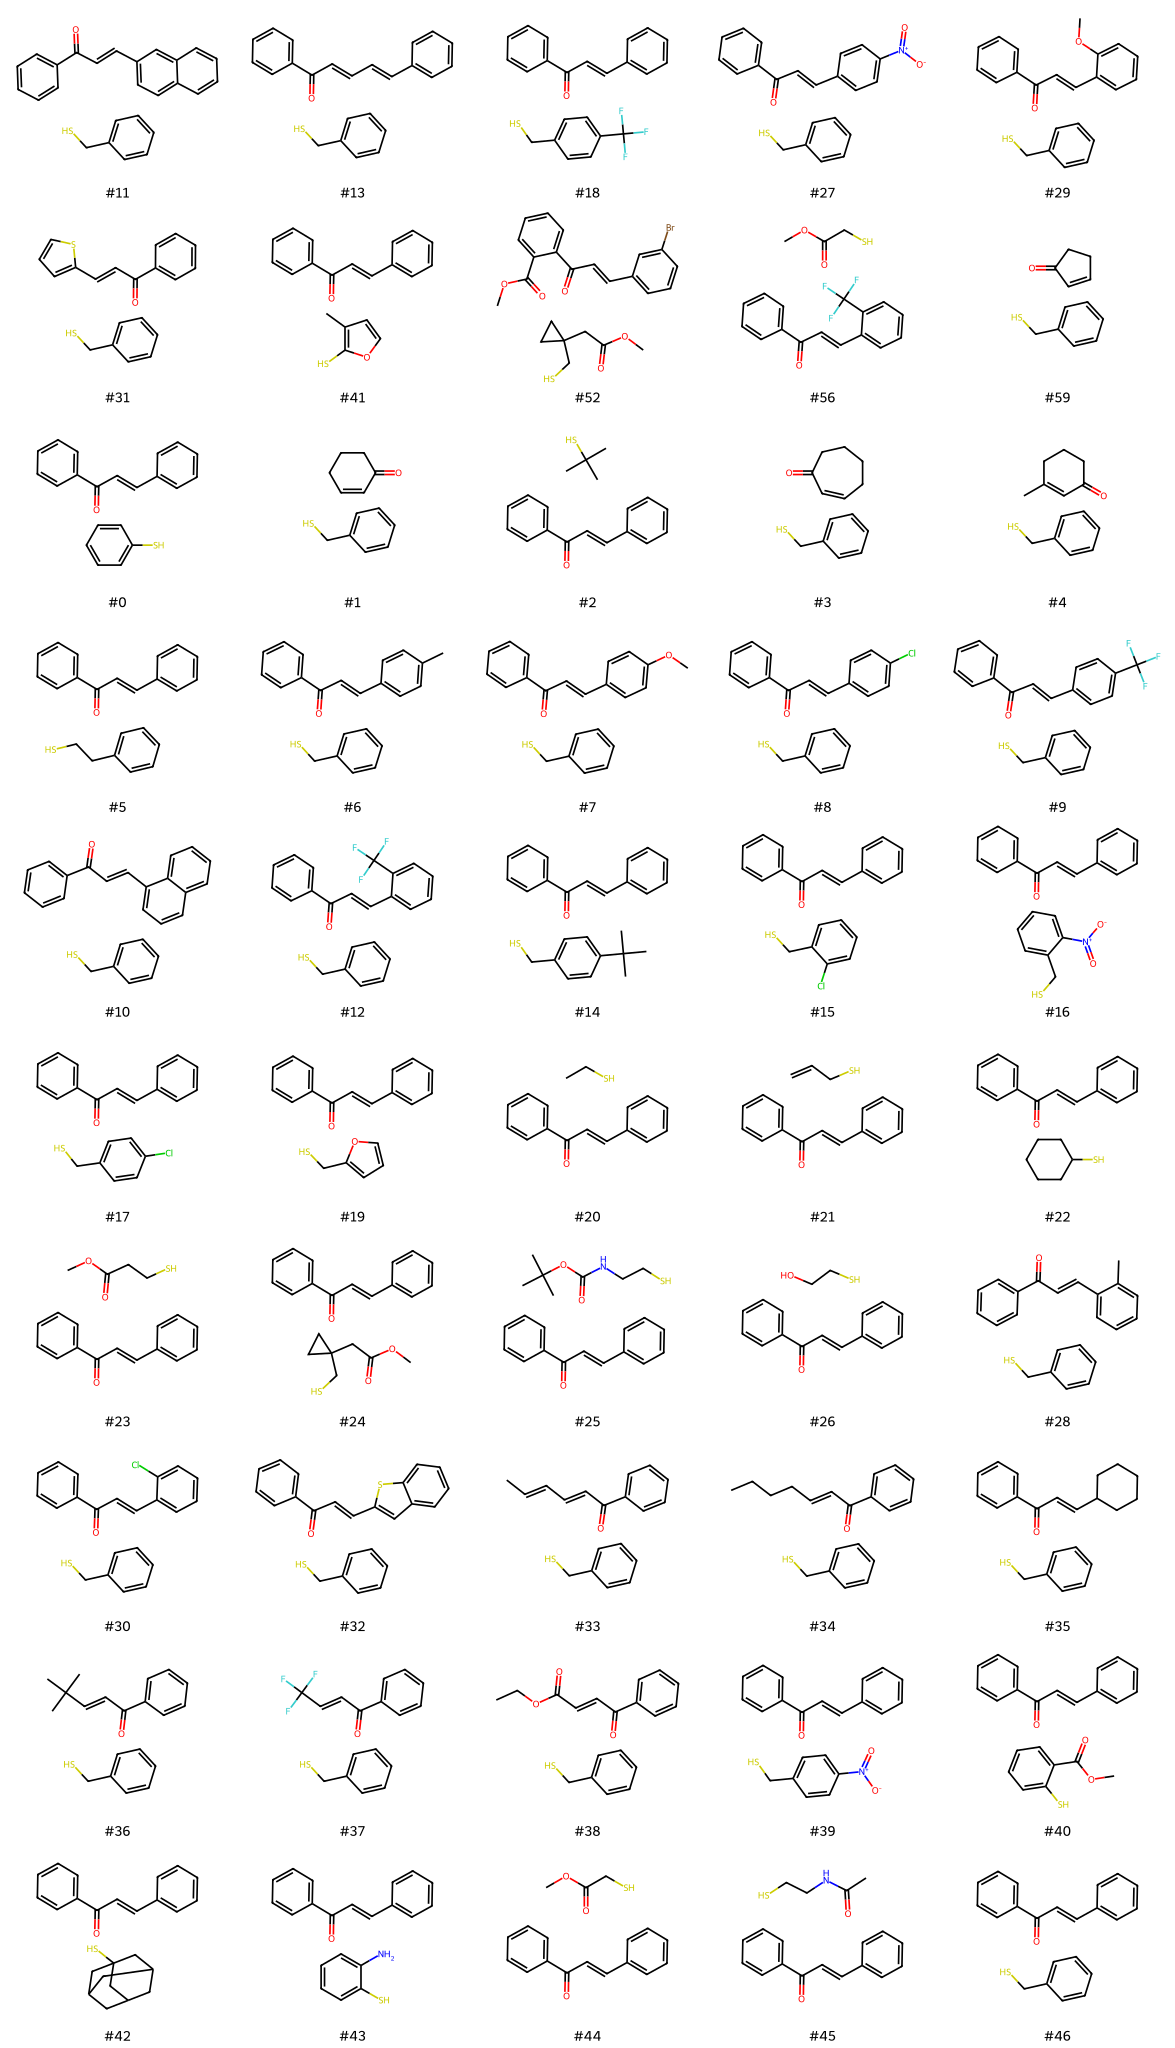

In [4]:
train_test_molgrid_svg = draw_train_test_molgrid(
    df=structures_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=100,#len(structures_df),
    img_size=(310, 270),
)

display(train_test_molgrid_svg)

In [10]:
def draw_train_test_molgrid(
    df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=8,
    max_mols=200,
    img_size=(310, 270),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        molecule = Chem.MolFromSmiles(
            str(row[smiles_col])
        )

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}\n"
            #f"{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError("No valid molecules were generated.")

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

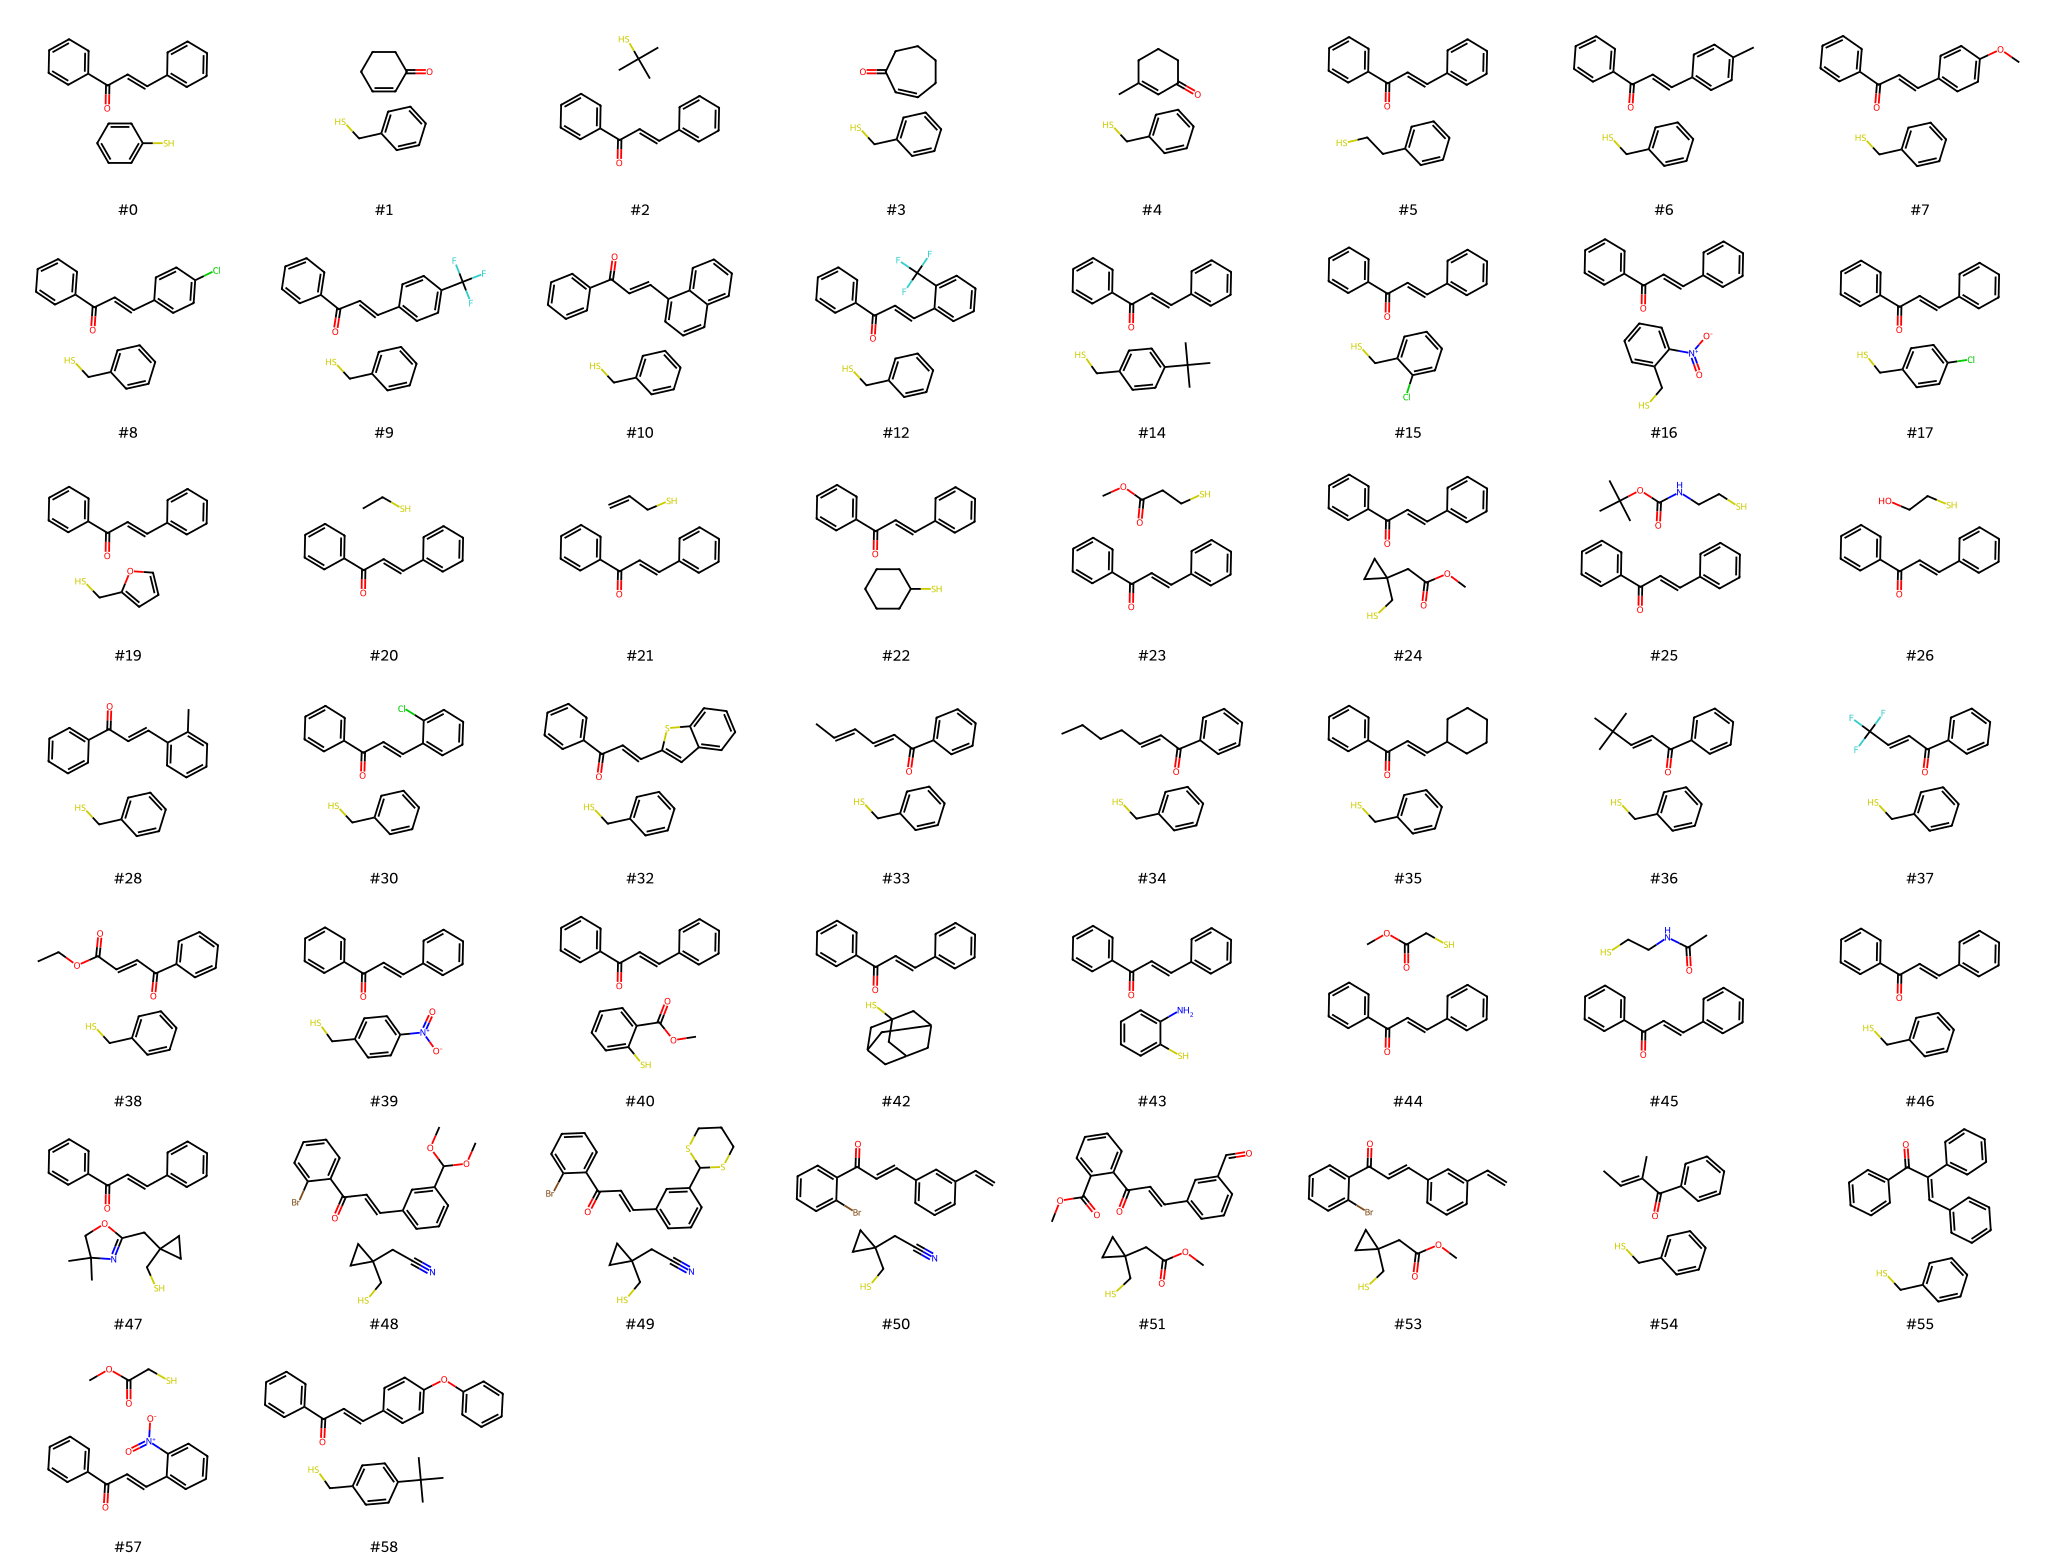

In [11]:
train_molgrid_svg = draw_train_test_molgrid(
    df=train_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=8,
    max_mols=len(train_df),
    img_size=(310, 270),
)

display(train_molgrid_svg)

In [12]:
from pathlib import Path

train_svg_file = Path(
    "Fig_S_thia_Michael_training_set_structures.svg"
)

with open(train_svg_file, "w", encoding="utf-8") as file:
    file.write(str(train_molgrid_svg))

print(f"Saved training SVG: {train_svg_file.resolve()}")

Saved training SVG: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\thia-Michael_regression\third_split\Kfold\substrate\no_chemberta_Kfold_Review_1\Data\Fig_S_thia_Michael_training_set_structures.svg


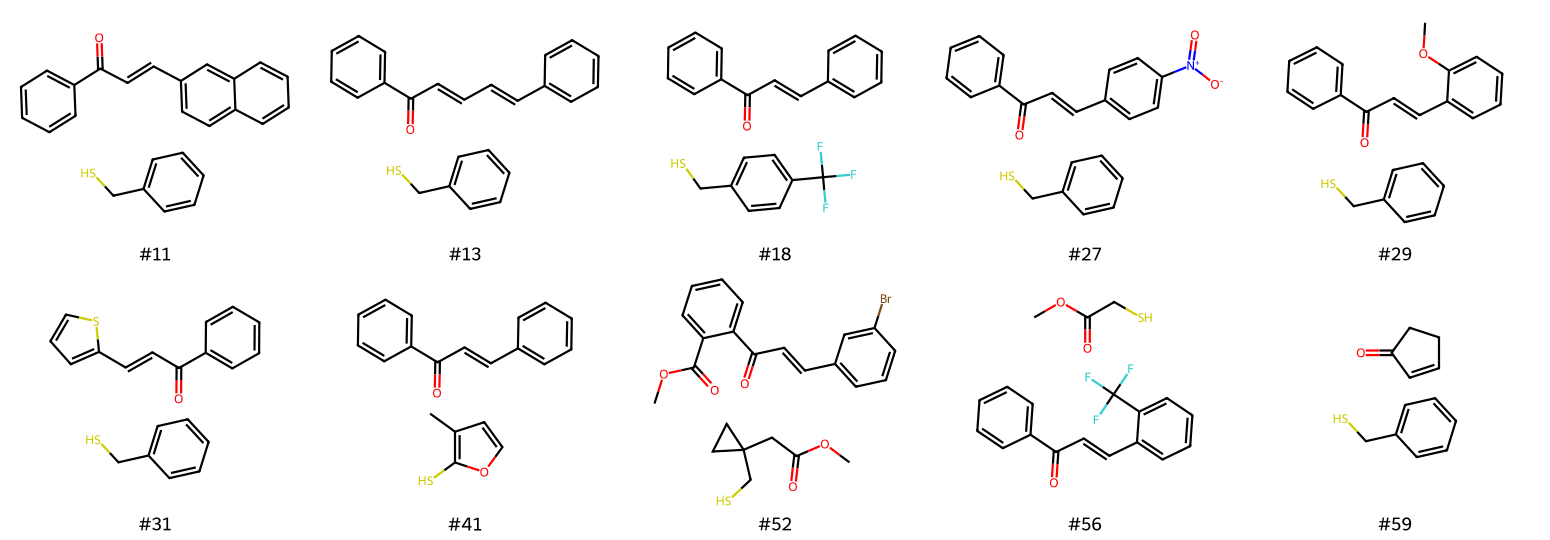

In [13]:
test_molgrid_svg = draw_train_test_molgrid(
    df=test_df,
    smiles_col="New_SMILES",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=len(test_df),
    img_size=(310, 270),
)

display(test_molgrid_svg)

In [14]:
test_svg_file = Path(
    "Fig_S_thia_Michael_development_test_set_structures.svg"
)

with open(test_svg_file, "w", encoding="utf-8") as file:
    file.write(str(test_molgrid_svg))

print(f"Saved test SVG: {test_svg_file.resolve()}")

Saved test SVG: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\thia-Michael_regression\third_split\Kfold\substrate\no_chemberta_Kfold_Review_1\Data\Fig_S_thia_Michael_development_test_set_structures.svg


In [16]:
from pathlib import Path

import pandas as pd

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D

data = pd.read_excel('Exp_verification_III_modyfikacja_10struktur.xlsx')

print("Shape:", data.shape)
print("Columns:")
print(data.columns.tolist())

print("\nDataset labels:")
#display(data["dataset"].value_counts(dropna=False))

display(data.head())

Shape: (10, 6)
Columns:
['l.p', 'SMILES_chalkon', 'SMILES_tiol', 'SMILES_produkt', 'experiment_ee', 'ee']

Dataset labels:


,l.p,SMILES_chalkon,SMILES_tiol,SMILES_produkt,experiment_ee,ee
0,26,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=CC=C2C(...,66.0,66.0
1,28,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,73.0,73.0
2,30,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=CC=C2)C3=CC=CC(...,27.0,27.0
3,31,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)C[C@H](SCC2=CC=C(C(C)(C)C)C=C2...,56.0,56.0
4,32,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2,SC(C)(C)C,O=C(C1=CC=CC=C1)C[C@H](SC(C)(C)C)C2=CC=C(OC3=C...,92.0,92.0


In [21]:
from pathlib import Path

import pandas as pd


EXPERIMENTAL_FILE = 'Exp_verification_III_modyfikacja_10struktur.xlsx'

experimental_df = pd.read_excel(
    EXPERIMENTAL_FILE
).copy()

required_columns = [
    "SMILES_tiol",
    "SMILES_chalkon",
]

missing_columns = [
    column
    for column in required_columns
    if column not in experimental_df.columns
]

assert not missing_columns, (
    f"Missing columns: {missing_columns}\n"
    f"Available columns: {experimental_df.columns.tolist()}"
)

# The Excel row order is the intended experimental-set numbering.
experimental_df = experimental_df.reset_index(drop=True)

experimental_df["Original_Index"] = (
    experimental_df.index + 1
)

experimental_df["Structure_ID"] = (
    "#"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["AD_ID"] = (
    "Exp #"
    + experimental_df["Original_Index"].astype(str)
)

experimental_df["Dataset_label"] = (
    "Experimental verification set"
)

assert len(experimental_df) == 10, (
    f"Expected 10 experimental examples, found {len(experimental_df)}."
)

display(
    experimental_df[
        [
            "Structure_ID",
            "AD_ID",
            "Original_Index",
            "Dataset_label",
            "SMILES_tiol",
            "SMILES_chalkon",
        ]
    ]
)

,Structure_ID,AD_ID,Original_Index,Dataset_label,SMILES_tiol,SMILES_chalkon
0,#1,Exp #1,1,Experimental verification set,SC(C)(C)C,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2C(F)(F)F
1,#2,Exp #2,2,Experimental verification set,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O
2,#3,Exp #3,3,Experimental verification set,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC=C2[N+]([O-])=O
3,#4,Exp #4,4,Experimental verification set,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC([N+]([O-])=O)=C2
4,#5,Exp #5,5,Experimental verification set,SC(C)(C)C,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2
5,#6,Exp #6,6,Experimental verification set,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=C(OC3=CC=CC=C3)C=C2
6,#7,Exp #7,7,Experimental verification set,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC(OC)=C2
7,#8,Exp #8,8,Experimental verification set,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CC(OC)=C2
8,#9,Exp #9,9,Experimental verification set,SCC1=CC=C(C(C)(C)C)C=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CN2
9,#10,Exp #10,10,Experimental verification set,SCC1=CC=CC=C1,O=C(C1=CC=CC=C1)/C=C/C2=CC=CN2


In [25]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D


def draw_experimental_molgrid(
    df,
    thiol_smiles_col="SMILES_tiol",
    chalcon_smiles_col="SMILES_chalcon",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=4,
    max_mols=200,
    img_size=(350, 300),
):
    molecules = []
    legends = []

    for dataframe_index, row in df.head(max_mols).iterrows():
        thiol_smiles = str(row[thiol_smiles_col])
        chalcon_smiles = str(row[chalcon_smiles_col])

        combined_smiles = (
            f"{thiol_smiles}.{chalcon_smiles}"
        )

        molecule = Chem.MolFromSmiles(combined_smiles)

        if molecule is None:
            print(
                f"SMILES conversion error: "
                f"{row[id_col]} (row {dataframe_index})"
            )
            continue

        molecules.append(molecule)

        legends.append(
            f"{row[id_col]}\n"
            #f"{row[dataset_label_col]}"
        )

    if not molecules:
        raise ValueError(
            "No valid molecules were generated."
        )

    draw_options = rdMolDraw2D.MolDrawOptions()
    draw_options.legendFontSize = 18
    draw_options.padding = 0.035
    draw_options.bondLineWidth = 2.2

    return Draw.MolsToGridImage(
        molecules,
        molsPerRow=n_per_row,
        subImgSize=img_size,
        legends=legends,
        useSVG=True,
        drawOptions=draw_options,
    )

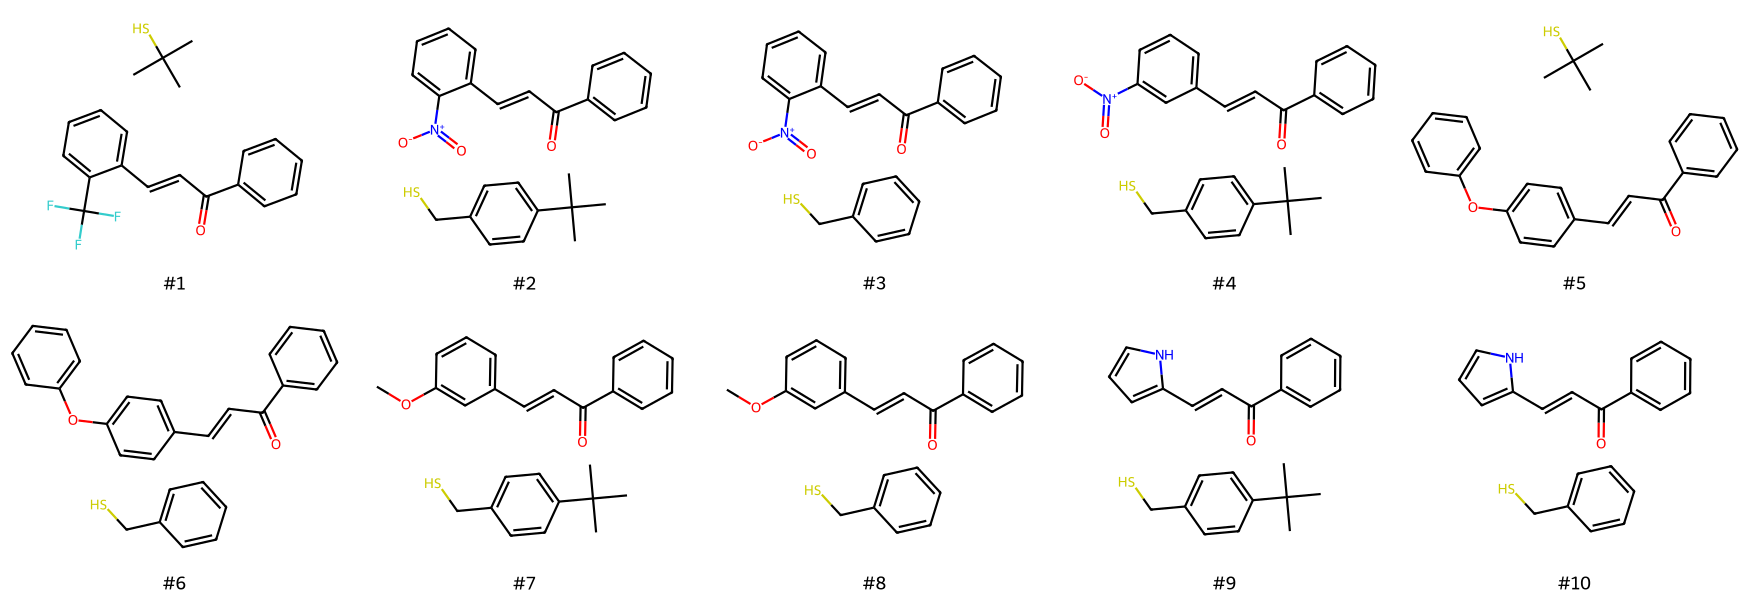

In [26]:
experimental_molgrid_svg = draw_experimental_molgrid(
    df=experimental_df,
    thiol_smiles_col="SMILES_tiol",
    chalcon_smiles_col="SMILES_chalkon",
    id_col="Structure_ID",
    #dataset_label_col="Dataset_label",
    n_per_row=5,
    max_mols=len(experimental_df),
    img_size=(350, 300),
)

display(experimental_molgrid_svg)

In [27]:
OUTPUT_DIR = Path("ReviewerValidation")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

experimental_svg_file = (
    OUTPUT_DIR
    / "Fig_S_thia_Michael_experimental_verification_structures.svg"
)

with open(experimental_svg_file, "w", encoding="utf-8") as file:
    file.write(str(experimental_molgrid_svg))

print(f"Saved SVG: {experimental_svg_file.resolve()}")

Saved SVG: C:\Users\aleks\Documents\GitHub\asymmetric-catalysis-qspr-ml\thia-Michael_regression\third_split\Kfold\substrate\no_chemberta_Kfold_Review_1\Data\ReviewerValidation\Fig_S_thia_Michael_experimental_verification_structures.svg
